# 휴먼 vs 매크로 행동 데이터 EDA

In [73]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import json
import numpy as np
import yaml
import seaborn as sns
import platform

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [74]:
# 노트북 세팅
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1000)

# 한글 폰트 적용

system = platform.system()

if system == "Darwin":  # macOS
    font_candidates = ["Nanum Gothic", "AppleGothic"]
elif system == "Windows":
    font_candidates = ["Malgun Gothic"]
else:  
    font_candidates = ["Nanum Gothic", "DejaVu Sans"]

for _font in font_candidates:
    try:
        plt.rcParams["font.family"] = _font
        print(f"한글 폰트 적용: {_font}")
        break
    except Exception:
        continue
plt.rcParams["axes.unicode_minus"] = False

한글 폰트 적용: Malgun Gothic


## 1. 데이터 준비

In [ ]:
# 데이터 경로 설정

ROOT = Path.cwd()

if(ROOT.name != "EDA"):
    raise Exception("데이터를 찾기 위해 작업 디렉토리 확인 필요")

TYPES = ["detail", "captcha", "booking"]
LABELS =  ["allow", "block"]

DATA_ROOT_DIR_V1 = Path("../../data/data_0514_1800_v1")
DATA_ROOT_DIR_V1 = Path("../../data/data_0514_1800_v2")

print(ROOT)

c:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\train\EDA
..\..\data\data_0514_1040_v2


In [ ]:
feature_config_path = Path("../../configs/feature_config.yaml")

with open(feature_config_path, "r", encoding="utf-8") as f:
    feature_config = yaml.safe_load(f)

FEATURE_GROUPS = feature_config["groups"]
FEATURE_NAME_KR = feature_config["names_ko"]

CLICK_FEATURES = FEATURE_GROUPS["click"]
MOUSE_FEATURES = FEATURE_GROUPS["mouse"]

BEHAVIOR_FEATURES = [f for group in FEATURE_GROUPS.values() for f in group]

feature_group_map = {
    feature: group
    for group, features in FEATURE_GROUPS.items()
    for feature in features
}

print("행동 feature 개수:", len(BEHAVIOR_FEATURES))

행동 feature 개수: 30


In [6]:
# 행동 데이터 로드

# label mapping map
label_map = {
    "ALLOW" : "human",
    "BLOCK" : "macro"
}

def load_data(data_dir: Path) -> pd.DataFrame:
    """데이터 로드

    Args:
        data_dir (Path): 데이터 디렉토리 경로
    Returns:
        pd.DataFrame: 행동 데이터프레임
    """

    rows: list[dict] = []
    
    for path in sorted(data_dir.glob("trial_*.json")):

        data = json.loads(path.read_text(encoding="utf-8"))
        label = label_map[data.get("label")]

        if(label is None):
            continue

        id = int(data.get("trialID"))
        feature = data.get("features", {})

        row = {
            "trial_id": id,
            "label": label,
        }

        if isinstance(feature, dict):
            row.update(feature)
        
        rows.append(row)
    
    df = pd.DataFrame(rows).sort_values("trial_id").reset_index(drop=True)
    return df

df = load_data(DATA_DIR)

print("데이터 개수:", len(df))
display(df.head())


데이터 개수: 490


,trial_id,label,reclick_rate,misclick_rate,mouse_jerk_mean,double_click_rate,mouse_overshoot_flag,mousemove_event_rate,pre_click_scroll_flag,time_to_first_click_ms,inter_click_interval_ms,mouse_acceleration_mean,mouse_speed_change_mean,pre_click_hover_time_ms,click_offset_variance_px,mouse_stop_segment_count,mouse_avg_speed_px_per_ms,mouse_hover_dwell_time_ms,mouse_max_speed_px_per_ms,mouse_path_curvature_mean,pre_click_mousemove_count,click_position_repeat_rate,mouse_direction_change_count,mouse_path_straightness_score,edge_or_fixed_point_visit_rate,mouse_total_travel_distance_px,click_sequence_consistency_score,immediate_post_render_click_rate,pre_click_path_300ms_straightness,pre_click_path_500ms_straightness,inter_element_move_interval_std_ms,click_offset_from_element_center_px,time_from_element_visible_to_click_ms,pre_click_path_300ms_total_distance_px,pre_click_path_500ms_total_distance_px,time_from_element_clickable_to_click_ms
0,690,human,0.0,0.000000,0.000185,0.285714,0,7.112835,0,6847,858.714286,0.010878,0.605931,172.714286,NaN,10.0,0.274939,172.714286,3.971109,0.057248,6.142857,0.0,21.0,0.141173,0.022727,3401.551199,0.0,0,1.00,0.12,NaN,50.331402,12287.000000,43,83,12379.000000
1,691,human,0.0,0.000000,0.000088,0.000000,0,13.381078,0,1692,509.500000,0.004700,0.280515,126.666667,9.401328,11.0,0.311655,126.666667,2.275434,0.072963,6.333333,0.0,26.0,0.093224,0.000000,1653.641413,1.0,0,1.00,1.00,9.5,11.453471,2178.333333,12,179,2186.333333
2,692,human,0.0,0.000000,0.000208,0.000000,0,10.097684,0,2711,1383.600000,0.010979,0.582735,169.800000,0.041177,13.0,0.386061,169.800000,10.080972,0.073135,6.400000,0.0,26.0,0.153864,0.000000,3517.400582,0.0,0,0.98,0.98,1619.0,10.891699,1961.000000,43,554,1970.000000
3,693,human,0.0,0.000000,0.000105,0.000000,1,10.654040,0,2601,776.000000,0.006606,0.388131,294.000000,NaN,5.0,0.268303,294.000000,2.657707,0.128139,5.000000,0.0,16.0,0.435865,0.027778,906.594965,0.0,0,1.00,0.48,NaN,15.206906,3337.000000,12,44,3377.000000
4,694,human,0.0,0.333333,0.000093,0.000000,0,10.235732,0,1630,1102.500000,0.004701,0.271625,180.666667,1076.325487,16.0,0.171093,180.666667,2.268127,0.159361,5.333333,0.0,30.0,0.024390,0.000000,1103.206819,1.0,0,1.00,1.00,438.5,35.678068,4196.666667,3,50,4216.000000


## 2. 데이터 전처리

## 3. 기본 분석

In [ ]:
# 행동 데이터 통계 요약

def feature_summary(df: pd.DataFrame) -> pd.DataFrame:
    """행동 데이터 통계 정보 요약 & 휴먼, 매크로 비교
    
    Args:
        df (pd.DataFrame): 행동 데이터프레임

    Returns:
        pd.DataFrame: 행동 feature 통계 요약 데이터프레임
    """

    n_rows = max(1, int(df.shape[0]))

    rows: list[dict] = []

    for feature in df.columns:

        s = df[feature].dropna()

        rows.append(
            {
                "group": feature_group_map.get(feature, "etc"),
                "feature": feature,
                "feature_ko": FEATURE_NAME_KR.get(feature),
                "count": int(s.shape[0]),
                "mean": float(s.mean()) if s.shape[0] else np.nan,
                "std": float(s.std()) if s.shape[0] else np.nan,
                "min": float(s.min()) if s.shape[0] else np.nan,
                "max": float(s.max()) if s.shape[0] else np.nan,
            }
        )

    return pd.DataFrame(rows)

human_df = df[df["label"] == "human"]
macro_df = df[df["label"] == "macro"]

human_summary = feature_summary(human_df)
macro_summary = feature_summary(macro_df)


In [8]:
# 행동 데이터 요약 결합(휴먼, 매크로) 및 SMD 계산 

levels = ["huge", "very_large", "large", "medium", "small"]

def merge_df(human_df: pd.DataFrame, macro_df: pd.DataFrame) -> tuple[pd.DataFrame, list[pd.DataFrame]]:
    """행동 데이터프레임 결합

    Args:
        human_df (pd.DataFrame): 휴먼 행동 데이터프레임
        macro_df (pd.DataFrame): 매크로 행동 데이터프레임 

    Returns:
        tuple[pd.DataFrame, list[pd.DataFrame]]: 결합된 비교 데이터프레임 / SMD level별 행동 데이터프레임 리스트
    """

    compare_summary = human_df.merge(
    macro_df,
    on=["feature_ko", "feature", "group"],
    suffixes=("_human", "_macro")
    )

    compare_summary["mean_diff"] = (
        compare_summary["mean_human"] - compare_summary["mean_macro"]
    )

    compare_summary["pooled_std"] = np.sqrt(
        (compare_summary["std_macro"]**2 + compare_summary["std_human"]**2) / 2
    )

    compare_summary["SMD"] = (
        compare_summary["mean_diff"] / compare_summary["pooled_std"]
    )

    compare_summary["abs_SMD"] = compare_summary["SMD"].abs()

    compare_summary = compare_summary[
        [
            "group",
            "feature_ko",
            "SMD",
            "mean_human",
            "mean_macro",
            "min_human",
            "min_macro",
            "max_human",
            "max_macro",
            "count_human",
            "count_macro",
            "abs_SMD",
            "feature"
        ]
    ]

    compare_summary["SMD_level"] = pd.cut(
        compare_summary["abs_SMD"],
        bins=[-float("inf"), 0.2, 0.5, 0.8, 1.5, 3.0, float("inf")],
        labels=["negligible", "small", "medium", "large", "very_large", "huge"]
    )

    summary_df: list[pd.DataFrame] = []
    for level in levels:
        summary_df.append(compare_summary[compare_summary["SMD_level"] == level])

    return compare_summary, summary_df

compare_summary, summary_df = merge_df(human_summary, macro_summary)

feature_smd_map = (
    compare_summary
    .set_index("feature")[["SMD_level", "abs_SMD"]]
    .apply(lambda row: (row["SMD_level"], row["abs_SMD"]), axis=1)
    .to_dict()
)

print("휴먼 데이터 수 : ", human_df.shape[0])
print("매크로 데이터 수 : ", macro_df.shape[0])


휴먼 데이터 수 :  30
매크로 데이터 수 :  460


In [9]:
print(feature_smd_map)

{'reclick_rate': ('negligible', 0.06593804733957867), 'misclick_rate': ('small', 0.23067227742616922), 'mouse_jerk_mean': ('large', 0.9102137545720718), 'double_click_rate': ('very_large', 1.6030997667910174), 'mouse_overshoot_flag': ('medium', 0.6042749026797891), 'mousemove_event_rate': ('very_large', 2.2741951015071966), 'pre_click_scroll_flag': (nan, nan), 'time_to_first_click_ms': ('negligible', 0.1085303445682659), 'inter_click_interval_ms': ('negligible', 0.1176483871856261), 'mouse_acceleration_mean': ('large', 0.8265065233007708), 'mouse_speed_change_mean': ('medium', 0.5338532641189445), 'pre_click_hover_time_ms': ('large', 1.0047082721002987), 'click_offset_variance_px': ('large', 0.9896708608582667), 'mouse_stop_segment_count': ('medium', 0.7344215565926346), 'mouse_avg_speed_px_per_ms': ('negligible', 0.15808175285432216), 'mouse_hover_dwell_time_ms': ('large', 1.091057162761833), 'mouse_max_speed_px_per_ms': ('medium', 0.7139956731877376), 'mouse_path_curvature_mean': ('v

In [10]:
print("\n행동 feature 통계 요약 비교:")

print(f"\n1. {levels[0]}")
display(summary_df[0].sort_values("abs_SMD", ascending=False))


행동 feature 통계 요약 비교:

1. huge


,group,feature_ko,SMD,mean_human,mean_macro,min_human,min_macro,max_human,max_macro,count_human,count_macro,abs_SMD,feature,SMD_level


In [11]:
print(f"\n2. {levels[1]}")
display(summary_df[1].sort_values("abs_SMD", ascending=False))


2. very_large


,group,feature_ko,SMD,mean_human,mean_macro,min_human,min_macro,max_human,max_macro,count_human,count_macro,abs_SMD,feature,SMD_level
5,mouse,mousemove 빈도,2.274195,8.228153,1.633959,0.149410,0.308229,13.744428,11.583012,30,460,2.274195,mousemove_event_rate,very_large
26,mouse,300ms 경로 직선성,1.775855,0.644667,0.026000,0.000000,0.000000,1.000000,1.000000,30,460,1.775855,pre_click_path_300ms_straightness,very_large
18,click,클릭 전 이동 수,1.757636,4.495397,1.623608,0.000000,0.000000,7.000000,7.000000,30,460,1.757636,pre_click_mousemove_count,very_large
17,mouse,경로 곡률,1.746057,0.109868,0.025451,0.006789,0.000000,0.257848,0.327862,28,311,1.746057,mouse_path_curvature_mean,very_large
20,mouse,방향 전환 수,1.678221,20.464286,4.511254,0.000000,0.000000,37.000000,50.000000,28,311,1.678221,mouse_direction_change_count,very_large
3,click,더블클릭 비율,-1.603100,0.042381,0.459035,0.000000,0.000000,0.333333,0.833333,30,460,1.603100,double_click_rate,very_large


In [12]:
print(f"\n3. {levels[2]}")
display(summary_df[2].sort_values("abs_SMD", ascending=False))


3. large


,group,feature_ko,SMD,mean_human,mean_macro,min_human,min_macro,max_human,max_macro,count_human,count_macro,abs_SMD,feature,SMD_level
15,mouse,평균 dwell,1.091057,254.200170,107.115339,34.333333,0.000000e+00,653.000000,1588.000000,28,311,1.091057,mouse_hover_dwell_time_ms,large
11,click,클릭 전 hover,1.004708,237.353492,102.673631,1.000000,0.000000e+00,653.000000,1588.000000,30,460,1.004708,pre_click_hover_time_ms,large
12,etc,None,-0.989671,167.375149,797.244141,0.041177,4.176236e-01,1228.505356,1750.464626,18,297,0.989671,click_offset_variance_px,large
33,click,활성 후 클릭,-0.951746,6202.615000,114404.862324,1725.000000,3.950000e+02,45255.000000,667047.000000,30,460,0.951746,time_from_element_clickable_to_click_ms,large
30,click,노출 후 클릭,-0.951731,6182.320000,114386.765518,1698.000000,3.760000e+02,45228.000000,667037.000000,30,460,0.951731,time_from_element_visible_to_click_ms,large
2,mouse,저크 평균,0.910214,0.000142,0.000051,0.000045,7.653451e-07,0.000461,0.000742,26,167,0.910214,mouse_jerk_mean,large
9,mouse,가속도 변화,0.826507,0.008157,0.003796,0.000056,1.210819e-05,0.025218,0.040798,28,311,0.826507,mouse_acceleration_mean,large
31,mouse,300ms 경로 총거리,0.807708,29.966667,2.889130,0.000000,0.000000e+00,124.000000,703.000000,30,460,0.807708,pre_click_path_300ms_total_distance_px,large


In [13]:
print(f"\n4. {levels[3]}")
display(summary_df[3].sort_values("abs_SMD", ascending=False))


4. medium


,group,feature_ko,SMD,mean_human,mean_macro,min_human,min_macro,max_human,max_macro,count_human,count_macro,abs_SMD,feature,SMD_level
13,mouse,정지 구간 수,0.734422,9.464286,5.861736,1.000000,1.000000,23.000000,25.000000,28,311,0.734422,mouse_stop_segment_count,medium
32,mouse,500ms 경로 총거리,-0.726255,108.333333,285.486957,0.000000,0.000000,554.000000,764.000000,30,460,0.726255,pre_click_path_500ms_total_distance_px,medium
16,mouse,최대 속도,0.713996,4.063889,2.181398,0.319907,0.352000,10.982641,15.958471,28,311,0.713996,mouse_max_speed_px_per_ms,medium
29,etc,None,0.649105,24.413088,15.152292,7.101001,1.118034,66.060788,87.627473,30,460,0.649105,click_offset_from_element_center_px,medium
4,mouse,오버슈트 여부,0.604275,0.200000,0.017391,0.000000,0.000000,1.000000,1.000000,30,460,0.604275,mouse_overshoot_flag,medium
21,mouse,경로 직선성,-0.541252,0.252856,0.370297,0.024390,0.034471,0.984129,1.000000,28,311,0.541252,mouse_path_straightness_score,medium
10,mouse,속도 변화,-0.533853,0.503297,0.742099,0.024382,0.002930,1.577423,2.550444,28,311,0.533853,mouse_speed_change_mean,medium


In [14]:
print(f"\n5. {levels[4]}")
display(summary_df[4].sort_values("abs_SMD", ascending=False))


5. small


,group,feature_ko,SMD,mean_human,mean_macro,min_human,min_macro,max_human,max_macro,count_human,count_macro,abs_SMD,feature,SMD_level
22,mouse,고정점 방문률,0.263783,0.027544,0.005132,0.000000,0.0,0.615385,0.360000,28,311,0.263783,edge_or_fixed_point_visit_rate,small
23,mouse,총 이동 거리,0.252602,1909.548434,1574.514393,95.434383,176.0,4363.885288,7852.387583,28,311,0.252602,mouse_total_travel_distance_px,small
1,click,오클릭 비율,0.230672,0.054762,0.033723,0.000000,0.0,0.333333,0.333333,30,460,0.230672,misclick_rate,small
28,etc,None,0.226678,688.004303,550.363946,9.500000,0.0,1674.500000,1380.372300,18,297,0.226678,inter_element_move_interval_std_ms,small


(comment)

`small` 그룹은 `0.2 <= |SMD| < 0.5` 그룹


### 3-1 데이터 분포 시각화 (박스 플롯)

(comment)

- 우선 순위가 높은 huge, very_large 그룹의 feature들이 `실제로 휴먼과 매크로에 따라 분리가 잘되는 지` boxplot으로 확인
- `이상치, 결측치 때문에 SMD level이 잘못된 것은 아닌지 확인`

In [15]:
# SMD 기준 정렬

# abs_SMD 기준 feature 순서
smd_feature_order = (
    compare_summary.sort_values("abs_SMD", ascending=False)["feature"].tolist()
)

# feature별 SMD 순위
smd_rank = {
    feature: rank
    for rank, feature in enumerate(smd_feature_order)
}

# FEATURE_GROUPS는 유지하고, 그룹 내부만 SMD 순서로 정렬
FEATURE_GROUPS_SORTED = {
    group: sorted(
        features,
        key=lambda feature: smd_rank.get(feature, float("inf"))
    )
    for group, features in FEATURE_GROUPS.items()
}

In [16]:
N_COLS = 3
N_FEATURES = 6
MAX_STRIP_PER_LABEL = 300

def draw_boxplot(group: str, features: list[str]) -> None:
    """행동 feature 그룹별 boxplot 그리기
    
    Args:
        group (str): feature 그룹명
        features (list[str]): feature 이름 리스트
    """

    features =  [feature for feature in features if feature not in EXCLUDE_COL]

    if not features:
        print("skip:", group)
        return
    
    for start in range(0, len(features), N_FEATURES):
        subset = features[start: start + N_FEATURES]

        rows = int(np.ceil(len(subset) / N_COLS))

        fig, axes = plt.subplots(rows, N_COLS, figsize=(16, 4.6 * rows))

        axes = np.array(axes).reshape(rows, N_COLS)

        for i, feature in enumerate(subset):
            r = i // N_COLS
            c = i % N_COLS
            ax = axes[r, c]

            s = pd.to_numeric(df[feature], errors="coerce")

            plot_df = pd.DataFrame(
                {
                    "label": df["label"],
                    "value": s,
                }
            ).dropna()

            feature_ko = FEATURE_NAME_KR.get(feature, feature)

            if plot_df.empty:
                ax.set_title(f"[ {feature_ko} ]\n [ {feature} ]")
                ax.axis("off")
                continue

            sns.boxplot(
                data=plot_df,
                x="label",
                y="value",
                hue="label",
                order=["human", "macro"],
                hue_order=["human", "macro"],
                legend=False,
                dodge=False,
                ax=ax,
                fliersize=2,
            )

            strip_parts = []

            for label in ["human", "macro"]:
                part = plot_df[plot_df["label"] == label]

                if part.empty:
                    continue

                strip_parts.append(
                    part.sample(
                        min(len(part), MAX_STRIP_PER_LABEL),
                        random_state=42,
                    )
                )

            if strip_parts:
                strip_df = pd.concat(strip_parts, ignore_index=True)

                sns.stripplot(
                    data=strip_df,
                    x="label",
                    y="value",
                    ax=ax,
                    color="black",
                    alpha=0.25,
                    size=2,
                    jitter=0.22,
                )

            q_low = plot_df["value"].quantile(0.01)
            q_high = plot_df["value"].quantile(0.99)
            if q_high > q_low:
                ax.set_ylim(q_low, q_high)

            ax.set_title(f"[ {feature_ko} ] [ {feature_smd_map.get(feature, (None, None))[0]} ] [ {feature_smd_map.get(feature, (None, None))[1]:.2f} ]\n[ {feature} ]")
            ax.set_xlabel("")
            ax.set_ylabel("")

        total_axes = rows * N_COLS

        for j in range(len(subset), total_axes):
            r = j // N_COLS
            c = j % N_COLS
            axes[r, c].axis("off")

        fig.suptitle(
            f"Human vs Macro [{group}] Boxplots",
            y=1.02,
            fontsize=14,
        )

        plt.tight_layout()
        plt.show()

groups = []
features_list = []
for group, features in FEATURE_GROUPS_SORTED.items():
    groups.append(group)
    features_list.append(features)

print("Number of groups:", len(groups))

Number of groups: 2



1. 그룹: click


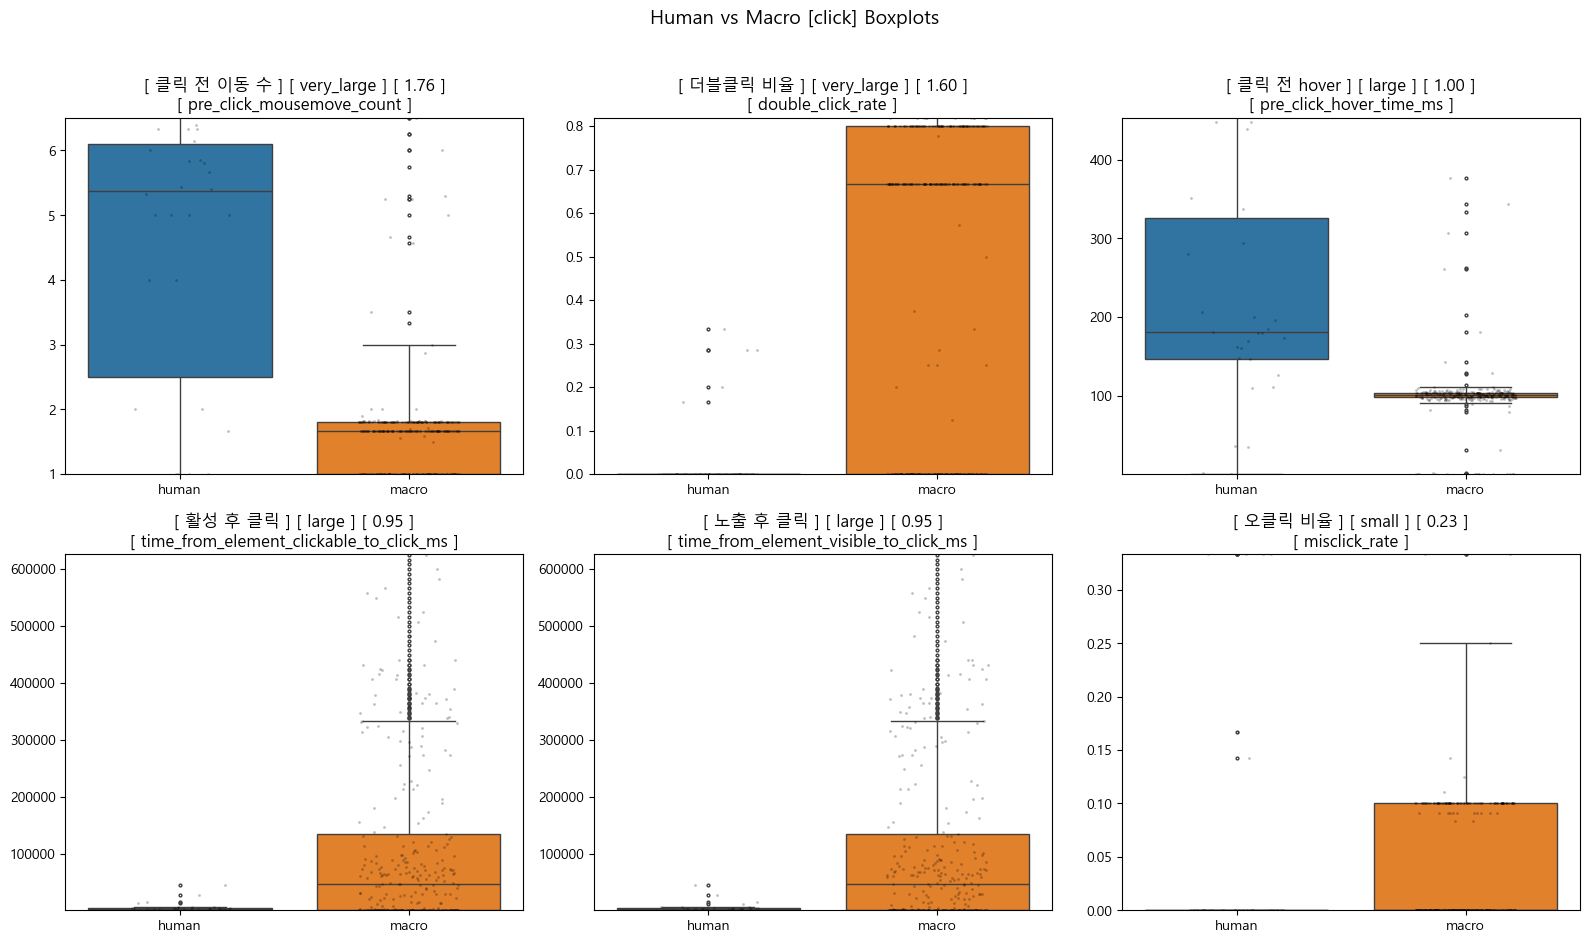

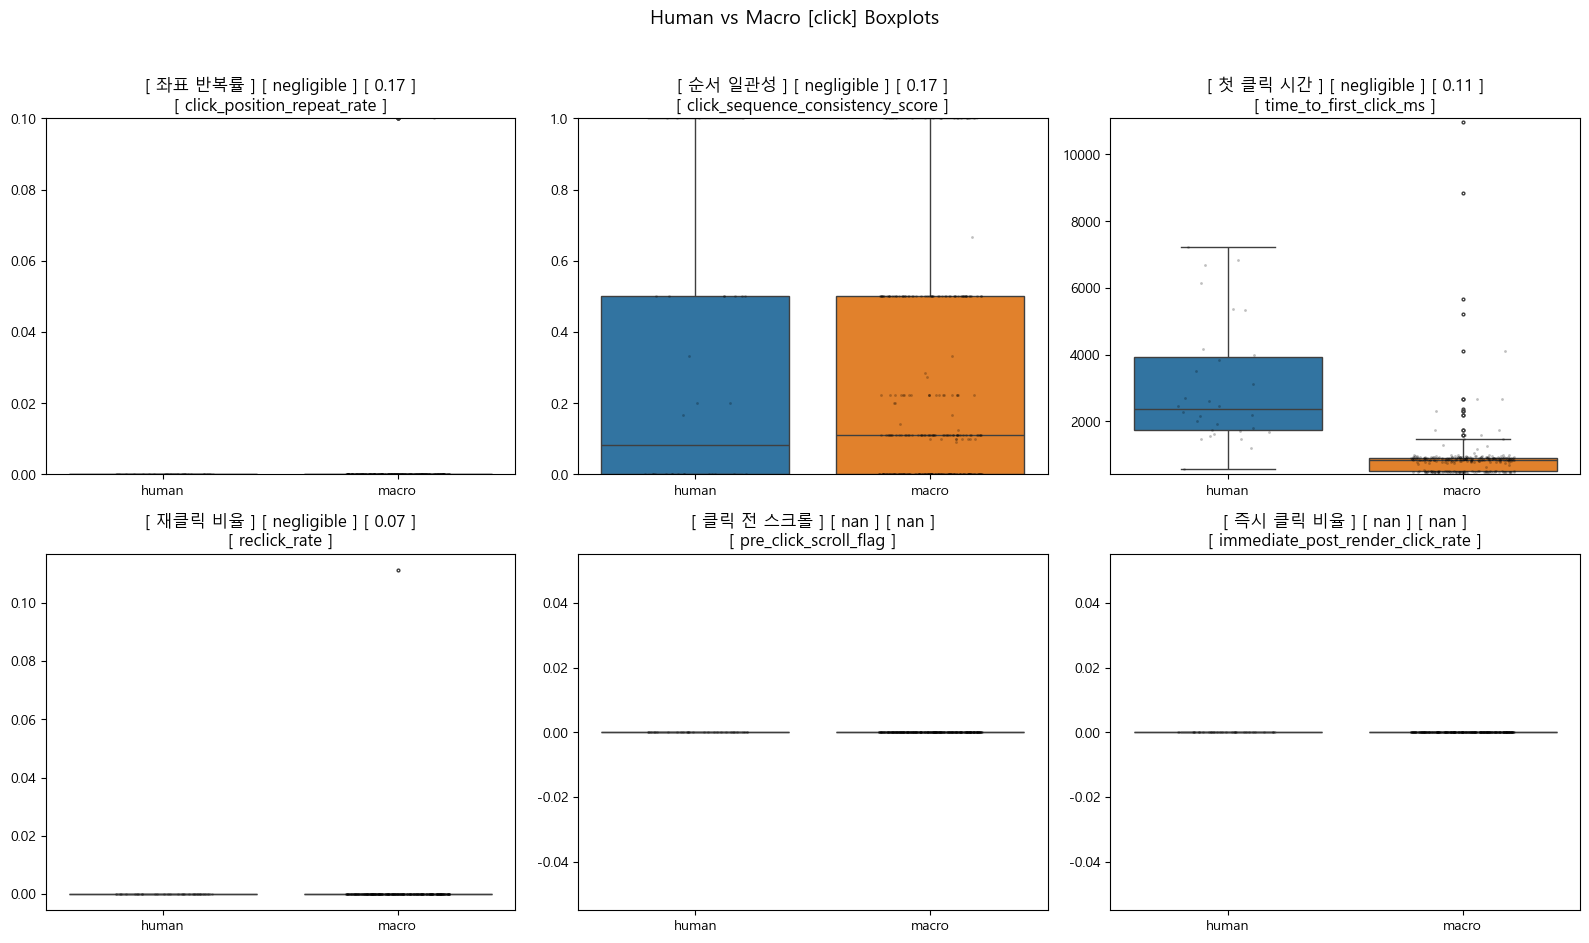

In [17]:
print("\n1. 그룹:", groups[0])
draw_boxplot(groups[0], features_list[0])


2. 그룹: mouse


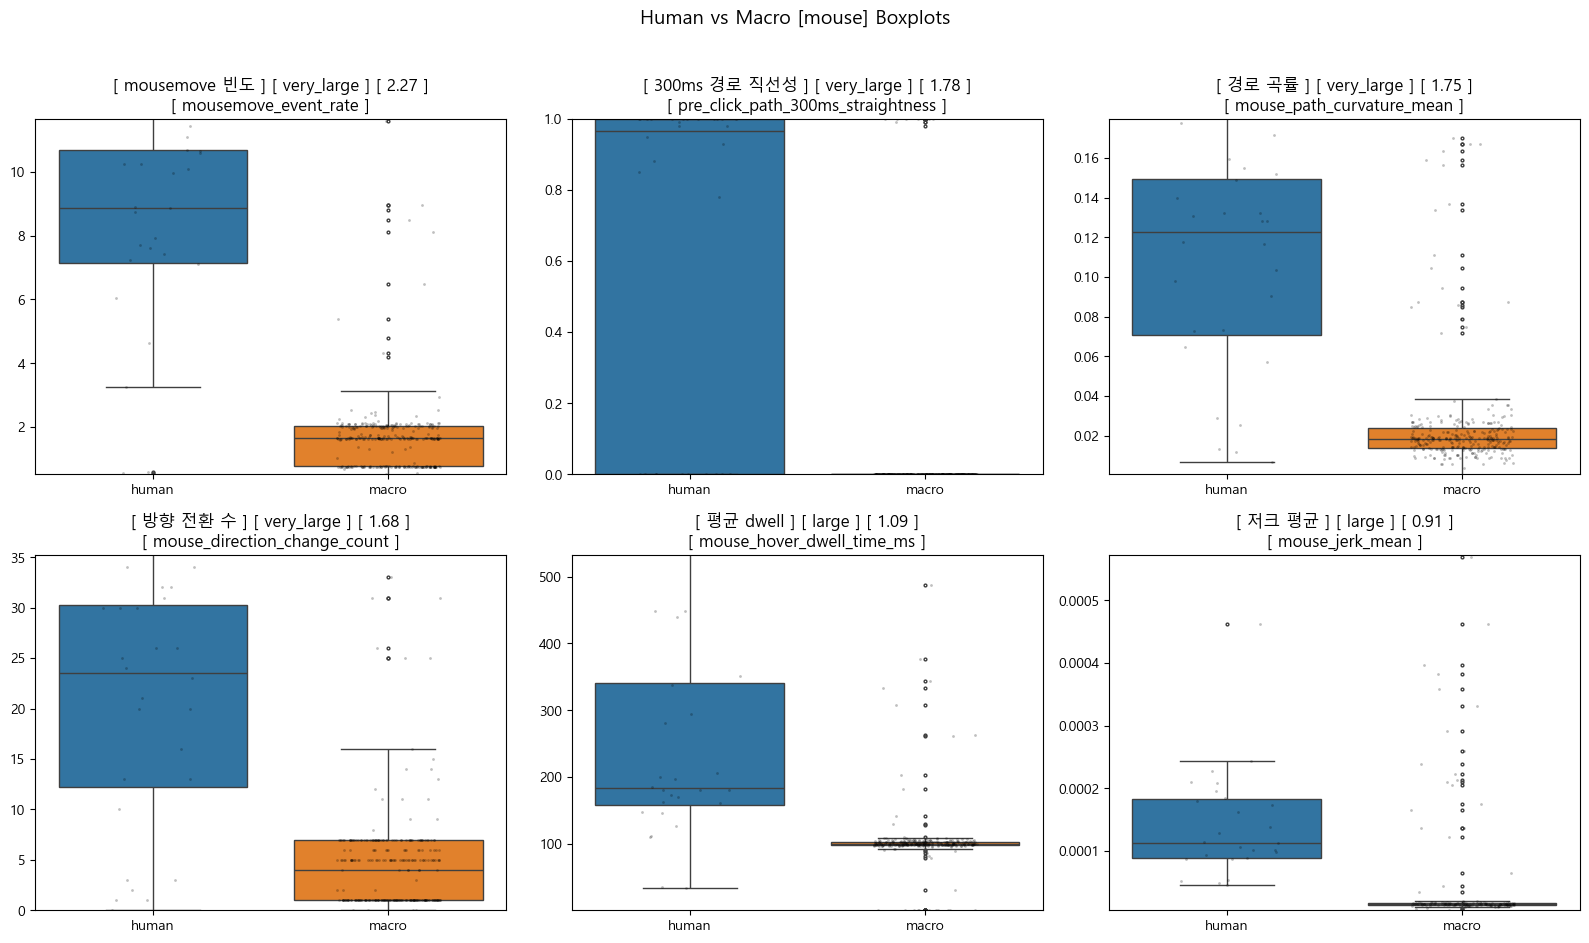

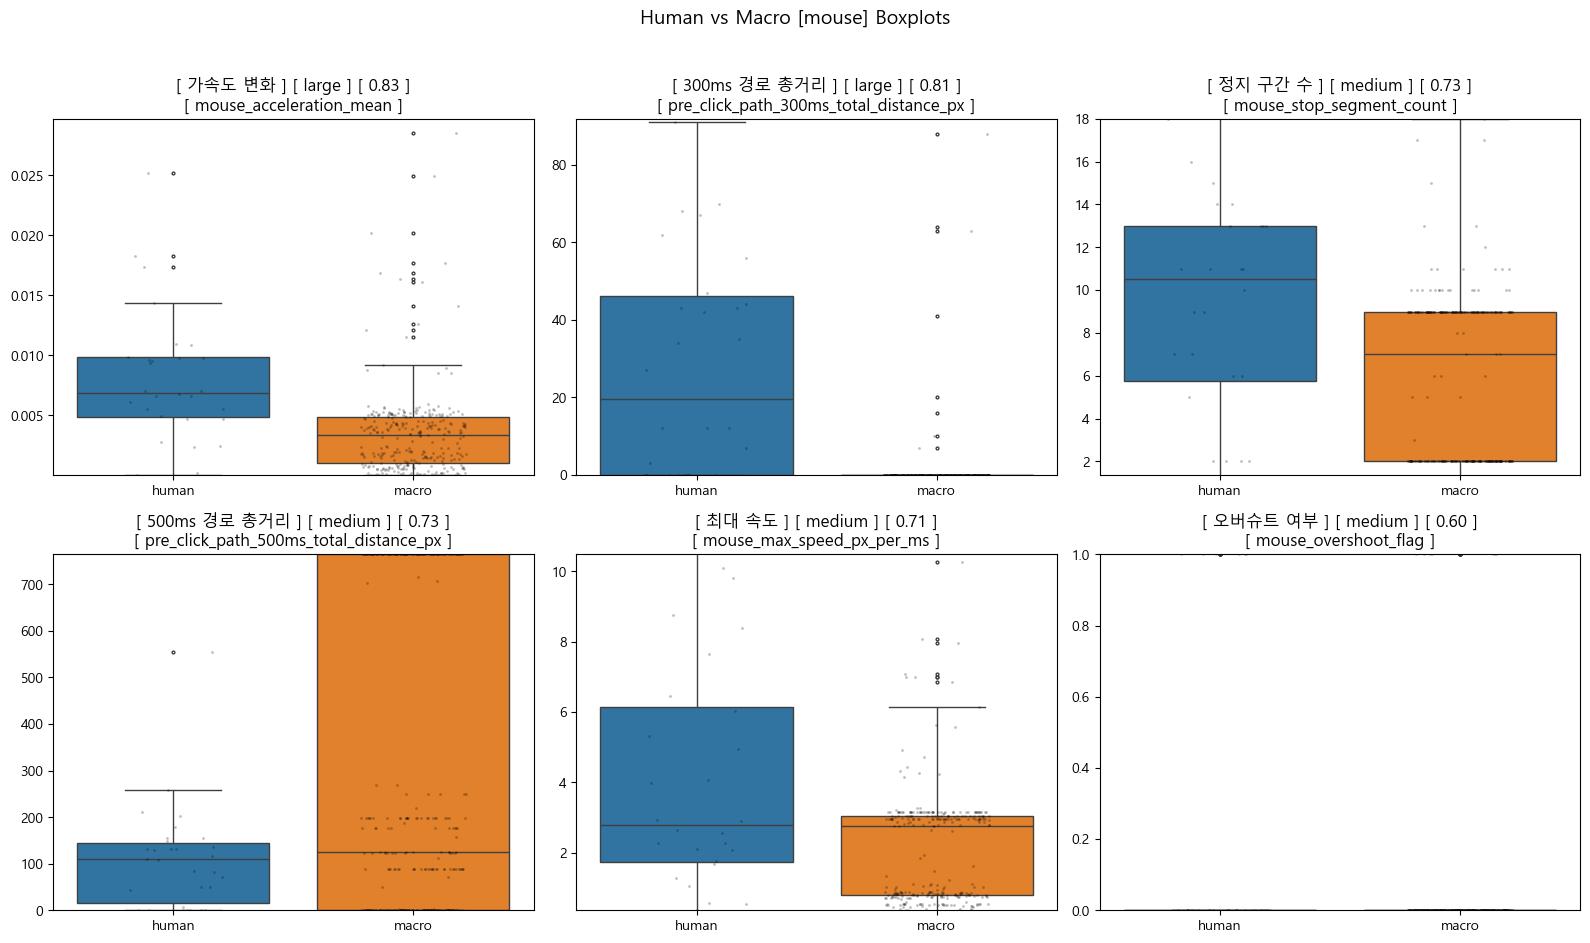

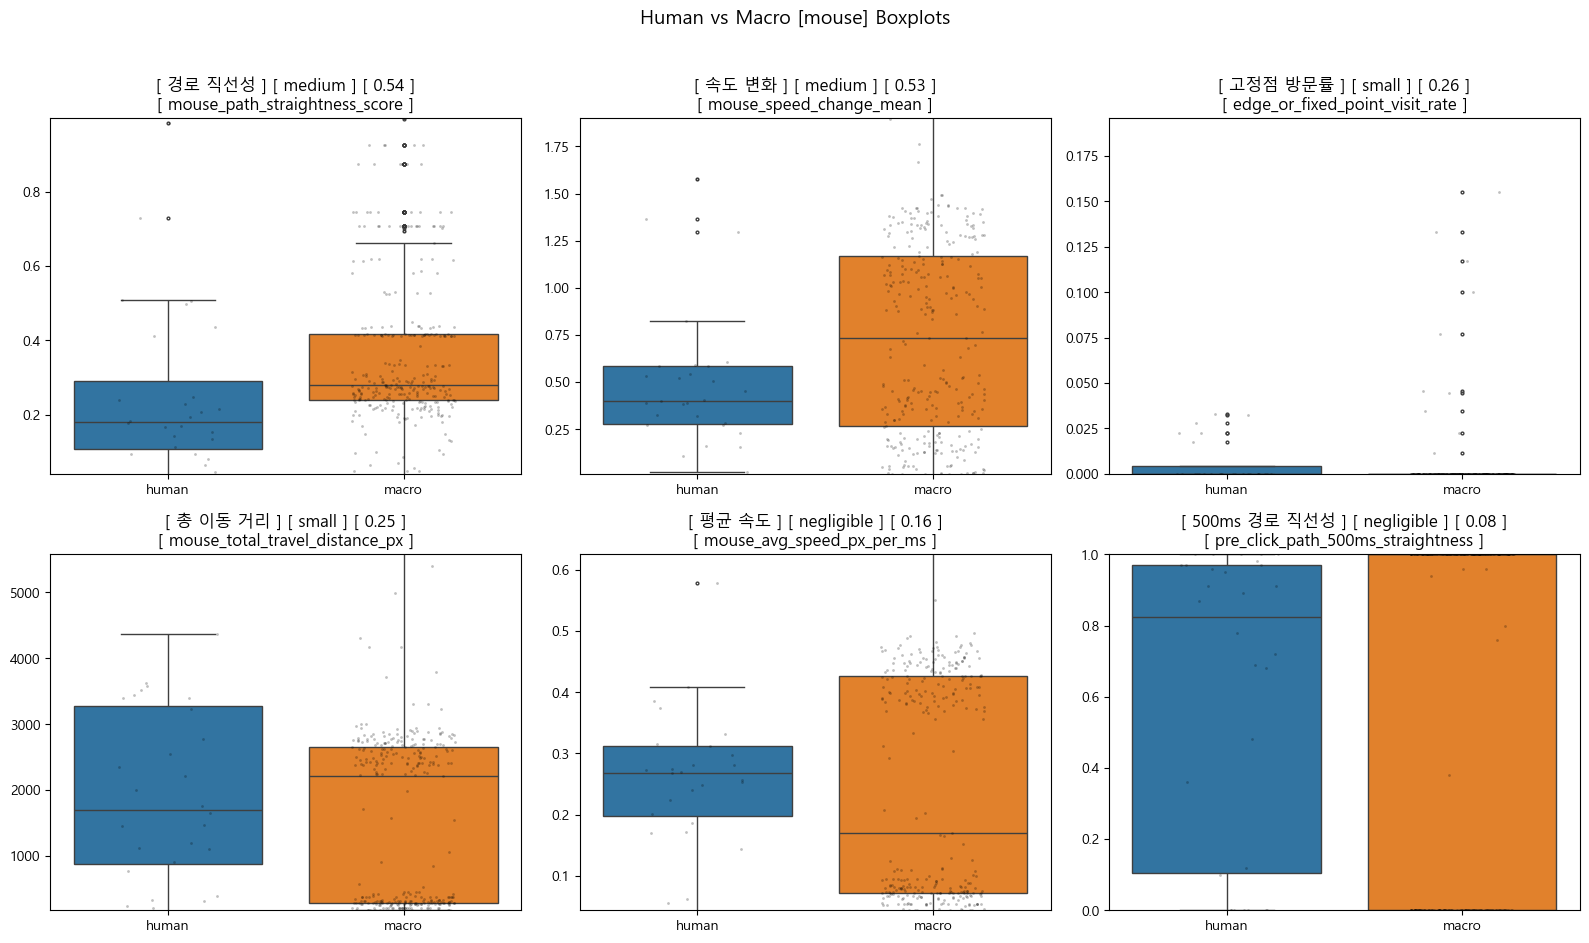

In [18]:
print("\n2. 그룹:", groups[1])
draw_boxplot(groups[1], features_list[1])

(comment)

huge, very_large 그룹 분리도 정확

### 3-2 상관관계 분석

(comment)

- 상관관계 0.9 이상의 feauture 그룹은 SMD 가장 높은 feature만 제외하고 제거
- 0.7 ~ 0.9의 강한 상관관계 그룹은 제거 후보로 기록

In [19]:
level_color_map = {
    "huge": "red",
    "very_large": "darkorange",
}

ko_feature_map = {
    ko: feature
    for feature, ko in FEATURE_NAME_KR.items()
}

def highlight_smd_level_ticks(ax, ko_feature_map: dict, feature_smd_map: dict, level_color_map: dict) -> None:
    """heatmap tick label을 SMD level 기준으로 강조"""

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        feature_ko = tick.get_text()
        feature = ko_feature_map.get(feature_ko)

        level, abs_smd = feature_smd_map.get(feature, (None, np.nan))

        if pd.isna(level):
            continue

        level = str(level)

        if level in level_color_map:
            tick.set_color(level_color_map[level])
            tick.set_fontweight("bold")

In [20]:
def draw_heatmap(group: str, features: list[str]) -> None:
    """행동 feature 그룹별 feature 간 상관관계 heatmap 그리기
    
    Args:
        group (str): feature 그룹명
        features (list[str]): feature 이름 리스트
    """

    features =  [feature for feature in features if feature not in EXCLUDE_COL]

    if not features:
        print("skip:", group)
        return

    corr_df = df[features].apply(pd.to_numeric, errors="coerce").corr()

    corr_df = corr_df.rename(
        index=FEATURE_NAME_KR,
        columns=FEATURE_NAME_KR
    )

    plt.figure(figsize=(12, 10))
    ax = sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
    plt.xticks(rotation=45, ha="right")

    highlight_smd_level_ticks(
        ax=ax,
        ko_feature_map=ko_feature_map,
        feature_smd_map=feature_smd_map,
        level_color_map=level_color_map,
    )

    plt.title(f"[ {group} ] Feature Correlation Heatmap")
    plt.show()




1. 그룹: click


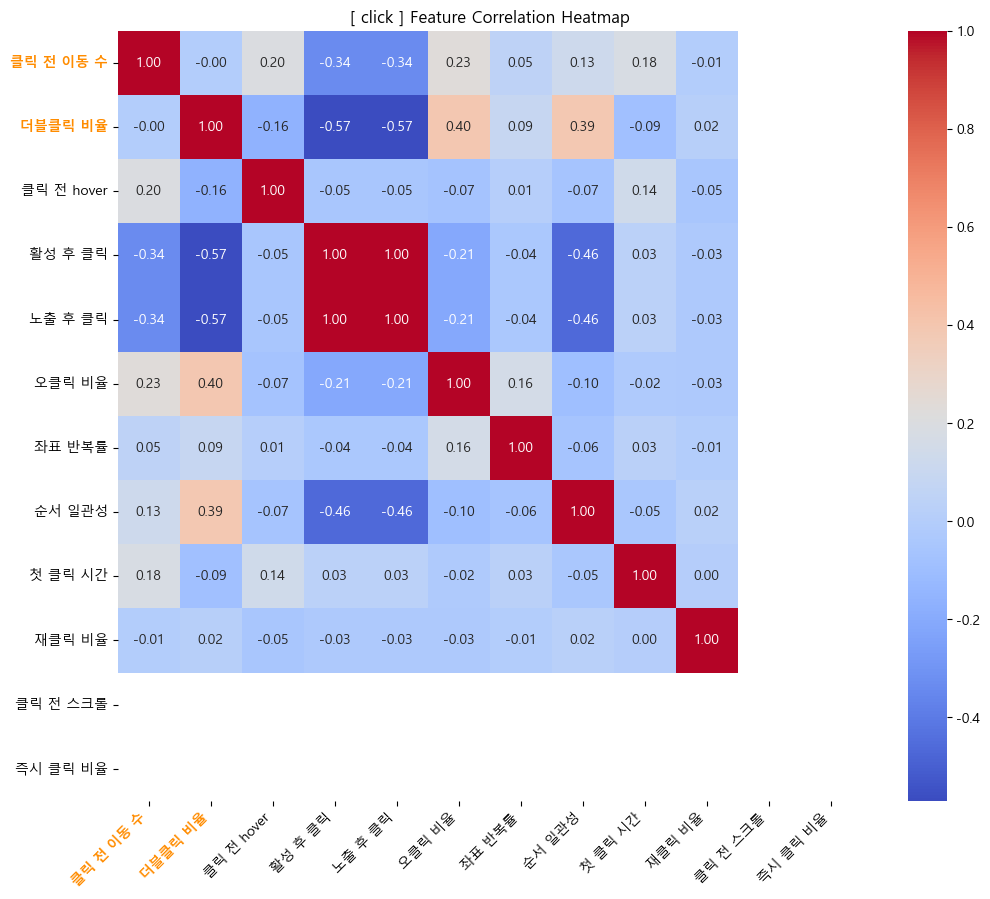

In [21]:
print("\n1. 그룹:", groups[0])
draw_heatmap(groups[0], features_list[0])

(comment)

huge, very_large 그룹 feature 상관관계 분석 (click)

- 0.9 이상
    - 노출 후 클릭, 활성화 후 클릭 (1.00) : 아주 강한 상관관계를 보임 -> SMD 지표 동일하므로 `노출 후 클릭`만 선택
    - 노출 후 클릭, 클릭 간격 (0.91) : 강한 상관관계를 보임 -> 클릭 간격은 수집 보류 상태이므로 일단 보류



2. 그룹: mouse


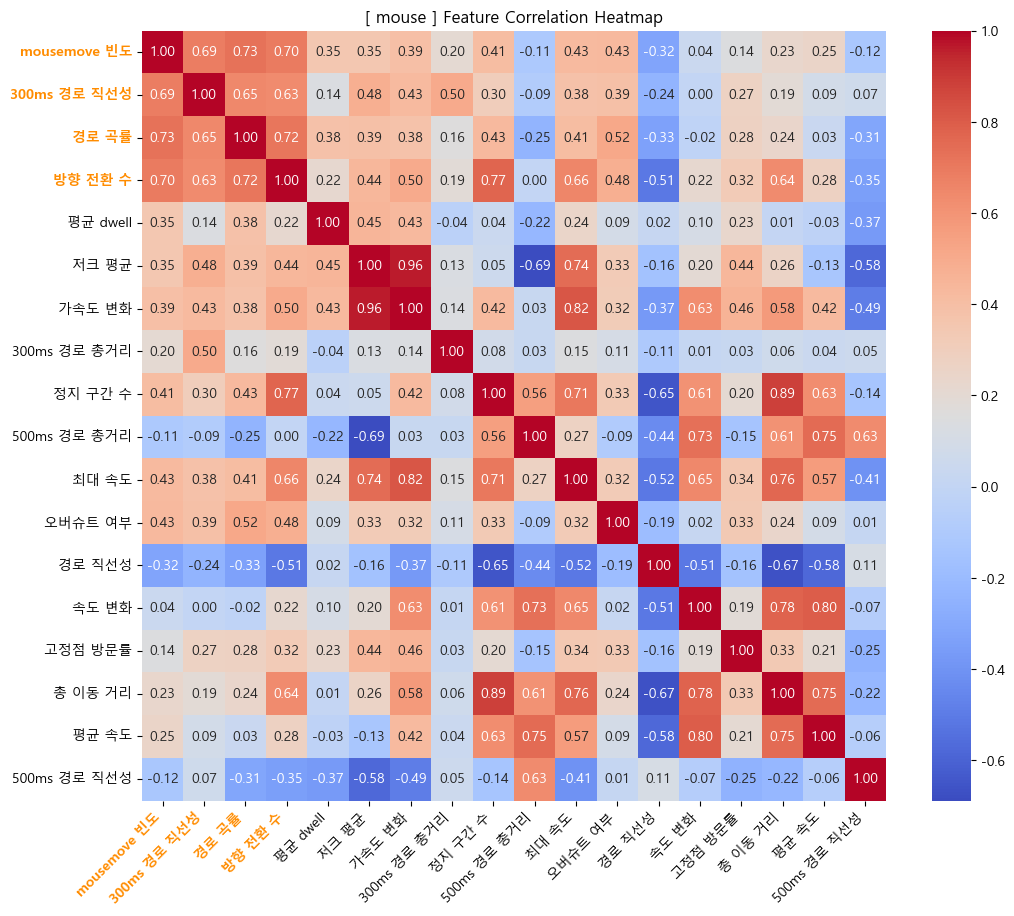

In [22]:
print("\n2. 그룹:", groups[1])
draw_heatmap(groups[1], features_list[1])

(comment)

huge, very_large 그룹 feature 상관관계 분석 (mouse)

- 0.7 ~ 0.9 : feature 많을 시 제거 후보 등록
    - mouse feature의 huge, very_large 그룹은 비교적 강한 상관관계를 보임


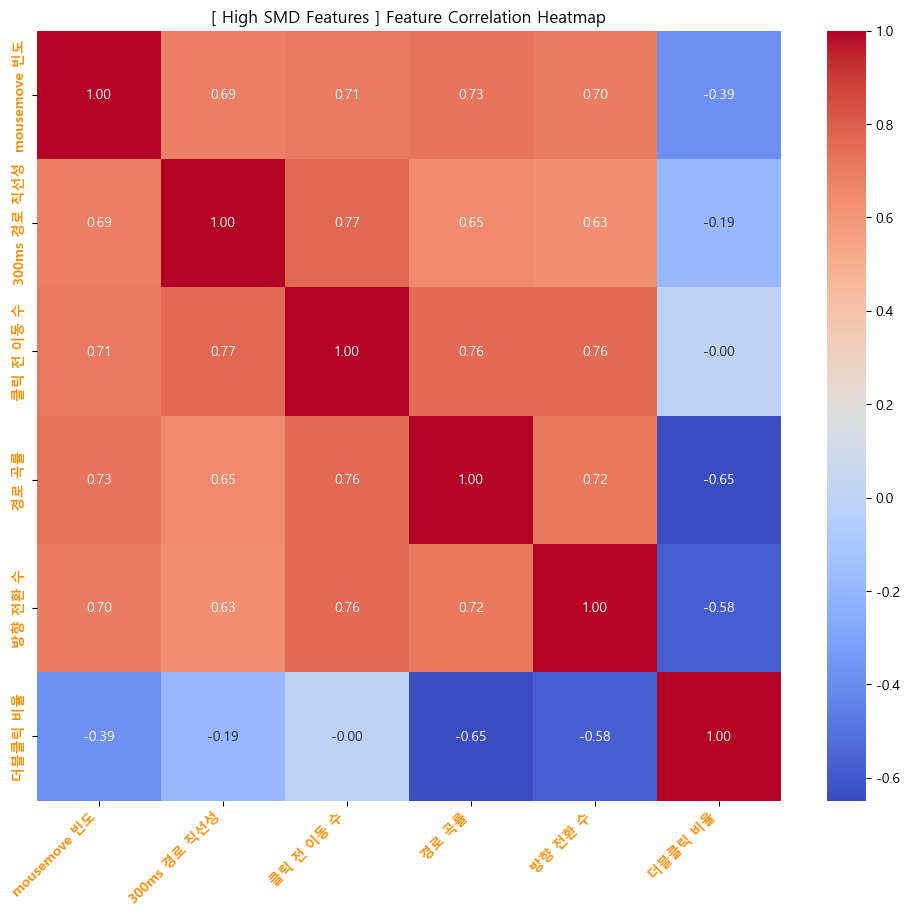

In [23]:
high_smd_features = [feature for feature, (level, abs_smd) in feature_smd_map.items() if level in ["huge", "very_large"] and feature_group_map.get(feature, "summary") != "summary"]

high_smd_features = sorted(
    high_smd_features,
    key=lambda feature: feature_smd_map[feature][1],
    reverse=True
)

draw_heatmap("High SMD Features", high_smd_features)

(comment)

- mousemove 빈도, 클릭 전 이동 수, 방향 전환 수 중 1~2개
- 노출 후 클릭, 활성 후 클릭 중 노출 후 클릭 선택
- 나머지 차용이 초기 셋팅으로 좋아보임

### 3-3 PCA

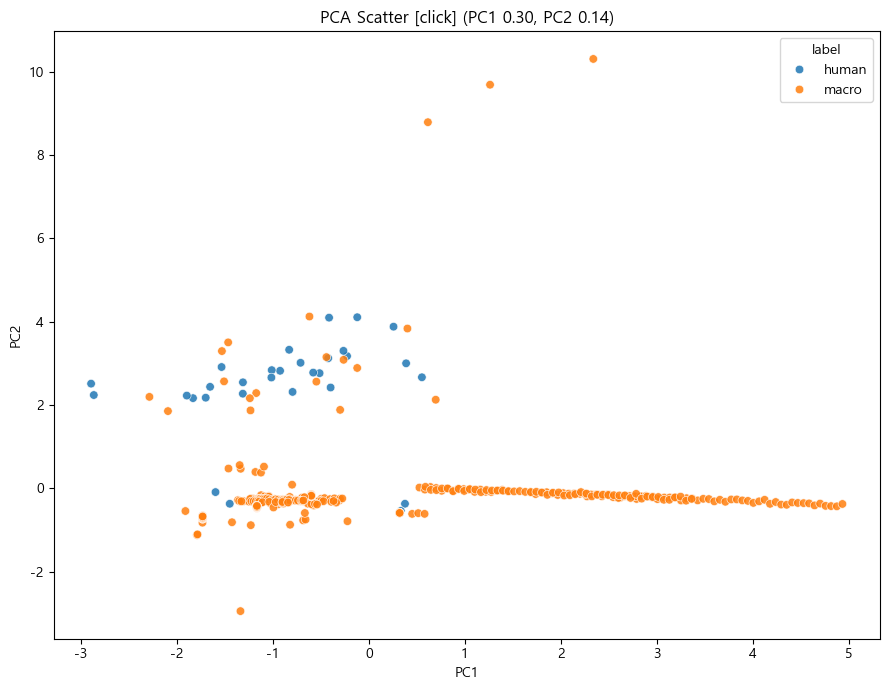

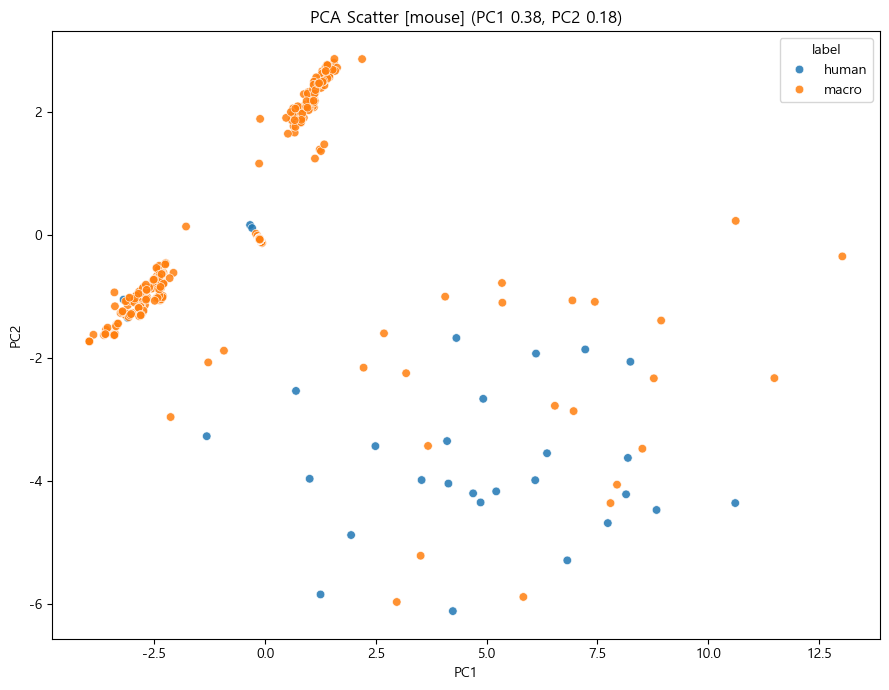

In [24]:
def draw_pca_scatter(title: str, features: list[str]) -> None:
    """PCA scatter plot 그리기
    
    Args:
        title (str): plot 제목
        features (list[str]): PCA에 사용할 feature 이름 리스트
    """

    features = [feature for feature in features if feature not in EXCLUDE_COL]

    if len(features) < 2:
        print("skip PCA:", title)
        return

    X = df[features].apply(pd.to_numeric, errors="coerce")

    features = [feature for feature in features if X[feature].notna().sum() > 0]

    if len(features) < 2:
        print("skip PCA:", title)
        return

    X = X[features]

    pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=2, random_state=42)),
        ]
    )

    xy = pipe.fit_transform(X)
    pca = pipe.named_steps["pca"]
    explained = pca.explained_variance_ratio_

    plt.figure(figsize=(9, 7))

    sns.scatterplot(
        x=xy[:, 0],
        y=xy[:, 1],
        hue=df["label"],
        s=38,
        alpha=0.85,
    )

    plt.title(
        f"PCA Scatter [{title}] "
        f"(PC1 {explained[0]:.2f}, PC2 {explained[1]:.2f})"
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

for group, features in FEATURE_GROUPS.items():
    draw_pca_scatter(group, features)

30


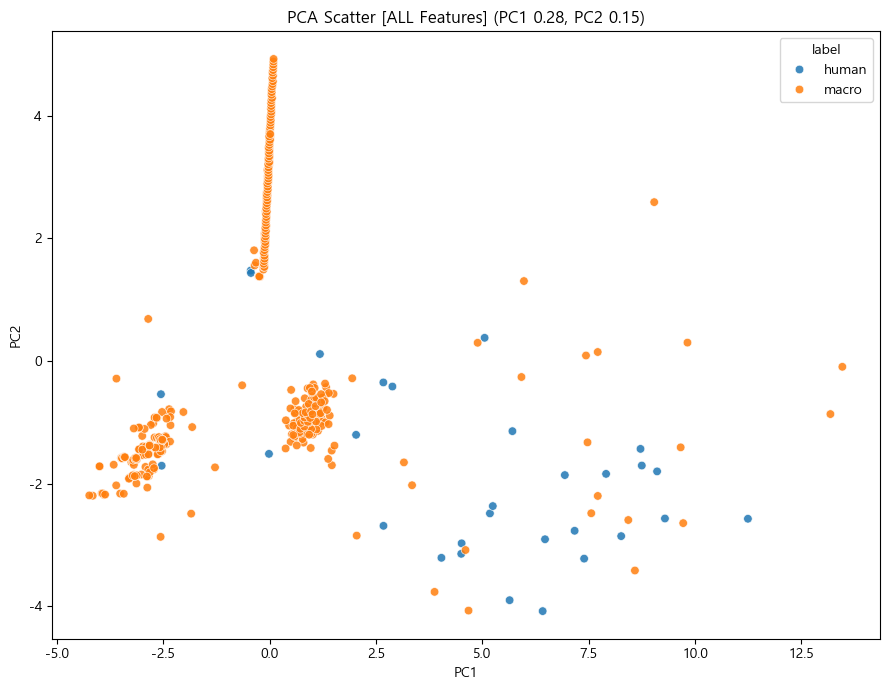

In [25]:
all_features = features_list[0] + features_list[1]
print(len(all_features))

draw_pca_scatter(
    title="ALL Features",
    features=features_list[0] + features_list[1]
)

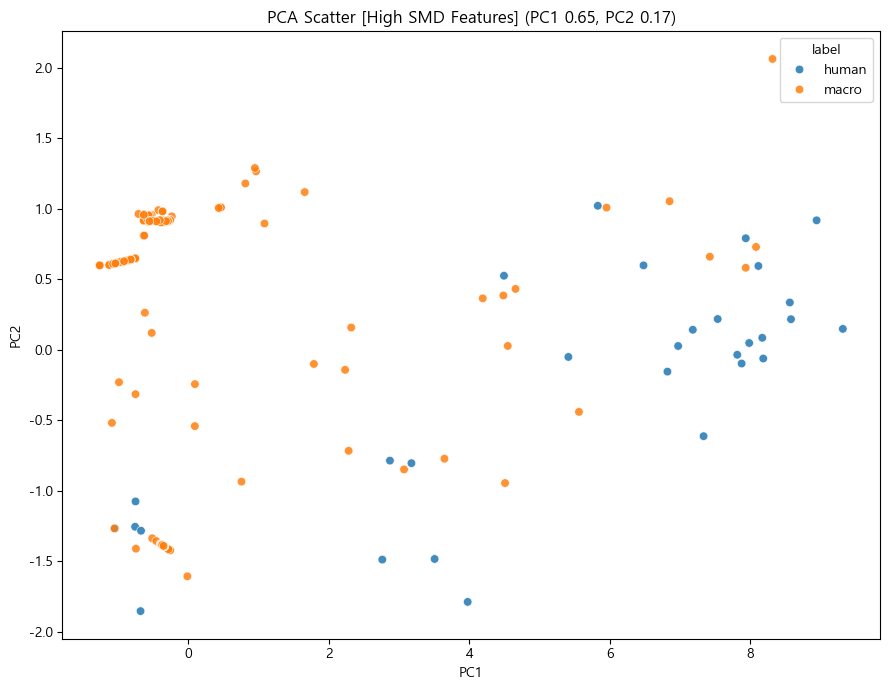

In [26]:
draw_pca_scatter(
    title="High SMD Features",
    features=high_smd_features,
)

In [27]:
print(high_smd_features)

['mousemove_event_rate', 'pre_click_path_300ms_straightness', 'pre_click_mousemove_count', 'mouse_path_curvature_mean', 'mouse_direction_change_count', 'double_click_rate']
